# Portfolio Optimization Dashboard

## Notebook 01: Market data acquisition

### Objectives

1. Download historical market data
2. Understand the dataset structure
3. Perform exploratory data analysis(EDA)
4. Prepare data for portfolio optimization



In [1]:
# install libraries
!pip -q install yfinance

In [2]:
# import libraries
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [3]:
# define portfolio
tickers = [
    "AAPL",
    "MSFT",
    "NVDA",
    "AMZN",
    "JPM"
]

start_date = "2019-01-10"
end_date = "2026-01-01"

In [4]:
#download data

data = yf.download(
    tickers=tickers,
    start=start_date,
    end=end_date,
    auto_adjust=True
    )

[*********************100%***********************]  5 of 5 completed


In [5]:
#Looking at the data
data.head()

Price           Close                                                  High  \
Ticker           AAPL       AMZN        JPM       MSFT      NVDA       AAPL   
Date                                                                          
2019-01-10  36.491665  82.810997  82.009773  96.503242  3.596157  36.532000   
2019-01-11  36.133392  82.028000  81.617653  95.758064  3.685299  36.467940   
2019-01-14  35.590046  80.860497  82.459076  95.059418  3.725165  35.891376   
2019-01-15  36.318459  83.727997  83.063599  97.816681  3.711051  36.394382   
2019-01-16  36.762150  84.189003  83.733467  98.161316  3.685546  36.985181   

Price                                                  ...       Open  \
Ticker           AMZN        JPM       MSFT      NVDA  ...       AAPL   
Date                                                   ...              
2019-01-10  83.162498  82.287527  96.642969  3.604823  ...  36.183217   
2019-01-11  83.014503  81.830045  96.354223  3.708080  ...  36.273383   
2019-01-14  82.410004  82.802177  95.823246  3.750422  ...  35.791724   
2019-01-15  83.758003  83.708960  97.853942  3.797221  ...  35.654110   
2019-01-16  85.250000  84.509531  98.981039  3.771221  ...  36.320833   

Price                                                     Volume             \
Ticker           AMZN        JPM       MSFT      NVDA       AAPL       AMZN   
Date                                                                          
2019-01-10  82.050499  81.707514  96.149276  3.511224  143122800  130154000   
2019-01-11  82.027496  81.601311  96.121348  3.573870  108092800   93724000   
2019-01-14  80.750000  80.768069  94.919692  3.633051  129756800  120118000   
2019-01-15  81.599998  80.784414  95.487934  3.757850  114843600  119970000   
2019-01-16  84.210999  83.529239  98.049541  3.738288  122278800  127338000   

Price                                      
Ticker           JPM      MSFT       NVDA  
Date                                       
2019-01-10  14376100  30067600  523156000  
2019-01-11  15439900  28314200  874764000  
2019-01-14  21258500  28437100  730168000  
2019-01-15  26504900  31587600  617012000  
2019-01-16  18533000  29853900  470104000  

[5 rows x 25 columns]

In [6]:
data.describe()

Price         Close                                                      \
Ticker         AAPL         AMZN          JPM         MSFT         NVDA   
count   1754.000000  1754.000000  1754.000000  1754.000000  1754.000000   
mean     148.586580   148.831210   149.029806   287.870409    50.050207   
std       60.881950    44.148421    62.732746   114.807724    55.617966   
min       35.590046    79.411003    66.463898    95.059418     3.258653   
25%      112.696491   105.925001   103.863783   202.932220    12.486086   
50%      150.042946   154.015747   131.606102   274.517700    21.277419   
75%      189.279884   178.031380   182.975590   392.258224    87.599913   
max      285.659271   254.000000   324.561249   538.658508   206.776276   

Price          High                                                      ...  \
Ticker         AAPL         AMZN          JPM         MSFT         NVDA  ...   
count   1754.000000  1754.000000  1754.000000  1754.000000  1754.000000  ...   
mean     150.085121   150.589167   150.423456   290.497052    50.898538  ...   
std       61.381081    44.561515    63.205759   115.555874    56.473921  ...   
min       35.891376    79.429497    70.433399    95.823246     3.411402  ...   
25%      114.263265   107.408627   105.052147   205.045229    12.750767  ...   
50%      151.767928   155.995750   132.710331   277.435513    21.871283  ...   
75%      190.727684   179.666382   183.945725   397.111527    89.325168  ...   
max      288.084759   258.600006   326.227587   551.048411   211.919725  ...   

Price          Open                                                      \
Ticker         AAPL         AMZN          JPM         MSFT         NVDA   
count   1754.000000  1754.000000  1754.000000  1754.000000  1754.000000   
mean     148.435962   148.875723   148.954797   287.803942    50.055700   
std       60.834232    44.240796    62.676298   114.880665    55.672960   
min       35.654110    79.300003    68.591617    94.919692     3.334672   
25%      112.793379   104.972498   103.918620   203.064709    12.511458   
50%      149.895625   154.134506   131.262803   274.693960    21.231939   
75%      188.921494   177.677502   182.641548   393.675465    87.417155   
max      285.669263   255.360001   324.502089   550.830123   207.814939   

Price         Volume                                                          
Ticker          AAPL          AMZN           JPM          MSFT          NVDA  
count   1.754000e+03  1.754000e+03  1.754000e+03  1.754000e+03  1.754000e+03  
mean    8.804208e+07  6.602857e+07  1.238499e+07  2.710813e+07  4.152385e+08  
std     5.054009e+07  3.308390e+07  6.484574e+06  1.186869e+07  2.016206e+08  
min     1.791060e+07  1.142050e+07  3.220500e+06  5.855900e+06  6.552850e+07  
25%     5.305188e+07  4.365422e+07  8.341375e+06  1.955378e+07  2.645921e+08  
50%     7.563410e+07  5.836745e+07  1.050110e+07  2.418545e+07  3.887150e+08  
75%     1.062268e+08  7.880850e+07  1.411925e+07  3.096390e+07  5.224752e+08  
max     4.265100e+08  3.113460e+08  5.441880e+07  9.701270e+07  2.511528e+09  

[8 rows x 25 columns]

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1754 entries, 2019-01-10 to 2025-12-31
Data columns (total 25 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   1754 non-null   float64
 1   (Close, AMZN)   1754 non-null   float64
 2   (Close, JPM)    1754 non-null   float64
 3   (Close, MSFT)   1754 non-null   float64
 4   (Close, NVDA)   1754 non-null   float64
 5   (High, AAPL)    1754 non-null   float64
 6   (High, AMZN)    1754 non-null   float64
 7   (High, JPM)     1754 non-null   float64
 8   (High, MSFT)    1754 non-null   float64
 9   (High, NVDA)    1754 non-null   float64
 10  (Low, AAPL)     1754 non-null   float64
 11  (Low, AMZN)     1754 non-null   float64
 12  (Low, JPM)      1754 non-null   float64
 13  (Low, MSFT)     1754 non-null   float64
 14  (Low, NVDA)     1754 non-null   float64
 15  (Open, AAPL)    1754 non-null   float64
 16  (Open, AMZN)    1754 non-null   float64
 17  (Open, JPM)    

In [8]:
data.columns

MultiIndex([( 'Close', 'AAPL'),
            ( 'Close', 'AMZN'),
            ( 'Close',  'JPM'),
            ( 'Close', 'MSFT'),
            ( 'Close', 'NVDA'),
            (  'High', 'AAPL'),
            (  'High', 'AMZN'),
            (  'High',  'JPM'),
            (  'High', 'MSFT'),
            (  'High', 'NVDA'),
            (   'Low', 'AAPL'),
            (   'Low', 'AMZN'),
            (   'Low',  'JPM'),
            (   'Low', 'MSFT'),
            (   'Low', 'NVDA'),
            (  'Open', 'AAPL'),
            (  'Open', 'AMZN'),
            (  'Open',  'JPM'),
            (  'Open', 'MSFT'),
            (  'Open', 'NVDA'),
            ('Volume', 'AAPL'),
            ('Volume', 'AMZN'),
            ('Volume',  'JPM'),
            ('Volume', 'MSFT'),
            ('Volume', 'NVDA')],
           names=['Price', 'Ticker'])

In [9]:
type(data.columns)

pandas.core.indexes.multi.MultiIndex

In [10]:
data.isnull().sum()

Price   Ticker
Close   AAPL      0
        AMZN      0
        JPM       0
        MSFT      0
        NVDA      0
High    AAPL      0
        AMZN      0
        JPM       0
        MSFT      0
        NVDA      0
Low     AAPL      0
        AMZN      0
        JPM       0
        MSFT      0
        NVDA      0
Open    AAPL      0
        AMZN      0
        JPM       0
        MSFT      0
        NVDA      0
Volume  AAPL      0
        AMZN      0
        JPM       0
        MSFT      0
        NVDA      0
dtype: int64

In [11]:
data.duplicated().sum()

np.int64(0)

In [12]:
data.index

DatetimeIndex(['2019-01-10', '2019-01-11', '2019-01-14', '2019-01-15',
               '2019-01-16', '2019-01-17', '2019-01-18', '2019-01-22',
               '2019-01-23', '2019-01-24',
               ...
               '2025-12-17', '2025-12-18', '2025-12-19', '2025-12-22',
               '2025-12-23', '2025-12-24', '2025-12-26', '2025-12-29',
               '2025-12-30', '2025-12-31'],
              dtype='datetime64[ns]', name='Date', length=1754, freq=None)

In [13]:
close_prices = data["Close"]
close_prices.head()

Ticker,AAPL,AMZN,JPM,MSFT,NVDA
Date,,,,,
2019-01-10,36.491665,82.810997,82.009773,96.503242,3.596157
2019-01-11,36.133392,82.028000,81.617653,95.758064,3.685299
2019-01-14,35.590046,80.860497,82.459076,95.059418,3.725165
2019-01-15,36.318459,83.727997,83.063599,97.816681,3.711051
2019-01-16,36.762150,84.189003,83.733467,98.161316,3.685546


In [14]:
close_prices.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1754 entries, 2019-01-10 to 2025-12-31
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL    1754 non-null   float64
 1   AMZN    1754 non-null   float64
 2   JPM     1754 non-null   float64
 3   MSFT    1754 non-null   float64
 4   NVDA    1754 non-null   float64
dtypes: float64(5)
memory usage: 82.2 KB


In [15]:
close_prices.describe()

Ticker,AAPL,AMZN,JPM,MSFT,NVDA
count,1754.000000,1754.000000,1754.000000,1754.000000,1754.000000
mean,148.586580,148.831210,149.029806,287.870409,50.050207
std,60.881950,44.148421,62.732746,114.807724,55.617966
min,35.590046,79.411003,66.463898,95.059418,3.258653
25%,112.696491,105.925001,103.863783,202.932220,12.486086
50%,150.042946,154.015747,131.606102,274.517700,21.277419
75%,189.279884,178.031380,182.975590,392.258224,87.599913
max,285.659271,254.000000,324.561249,538.658508,206.776276


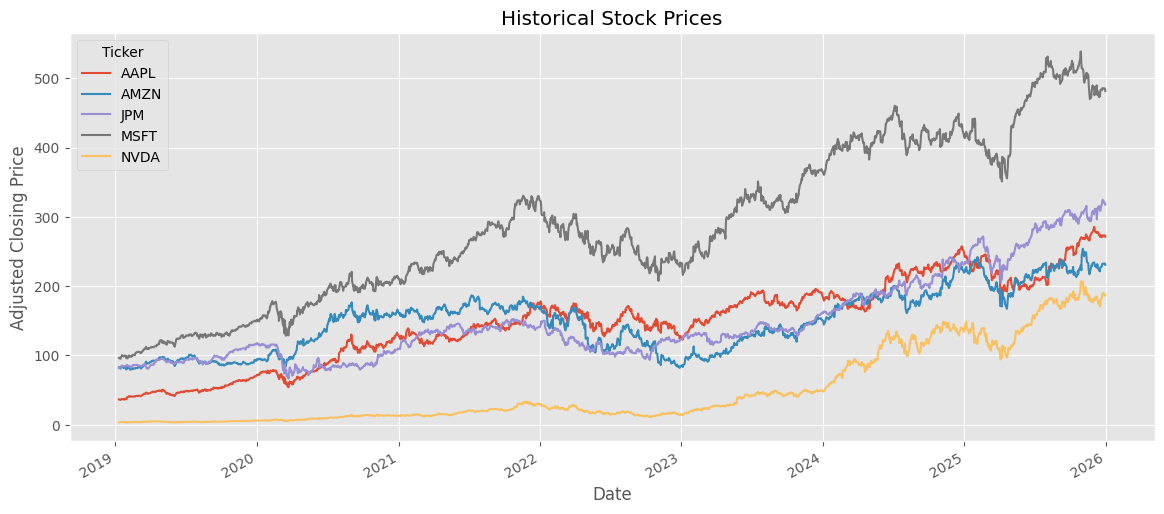

In [16]:
close_prices.plot(figsize=(14, 6))

plt.title("Historical Stock Prices")
plt.xlabel("Date")
plt.ylabel("Adjusted Closing Price")

plt.show()

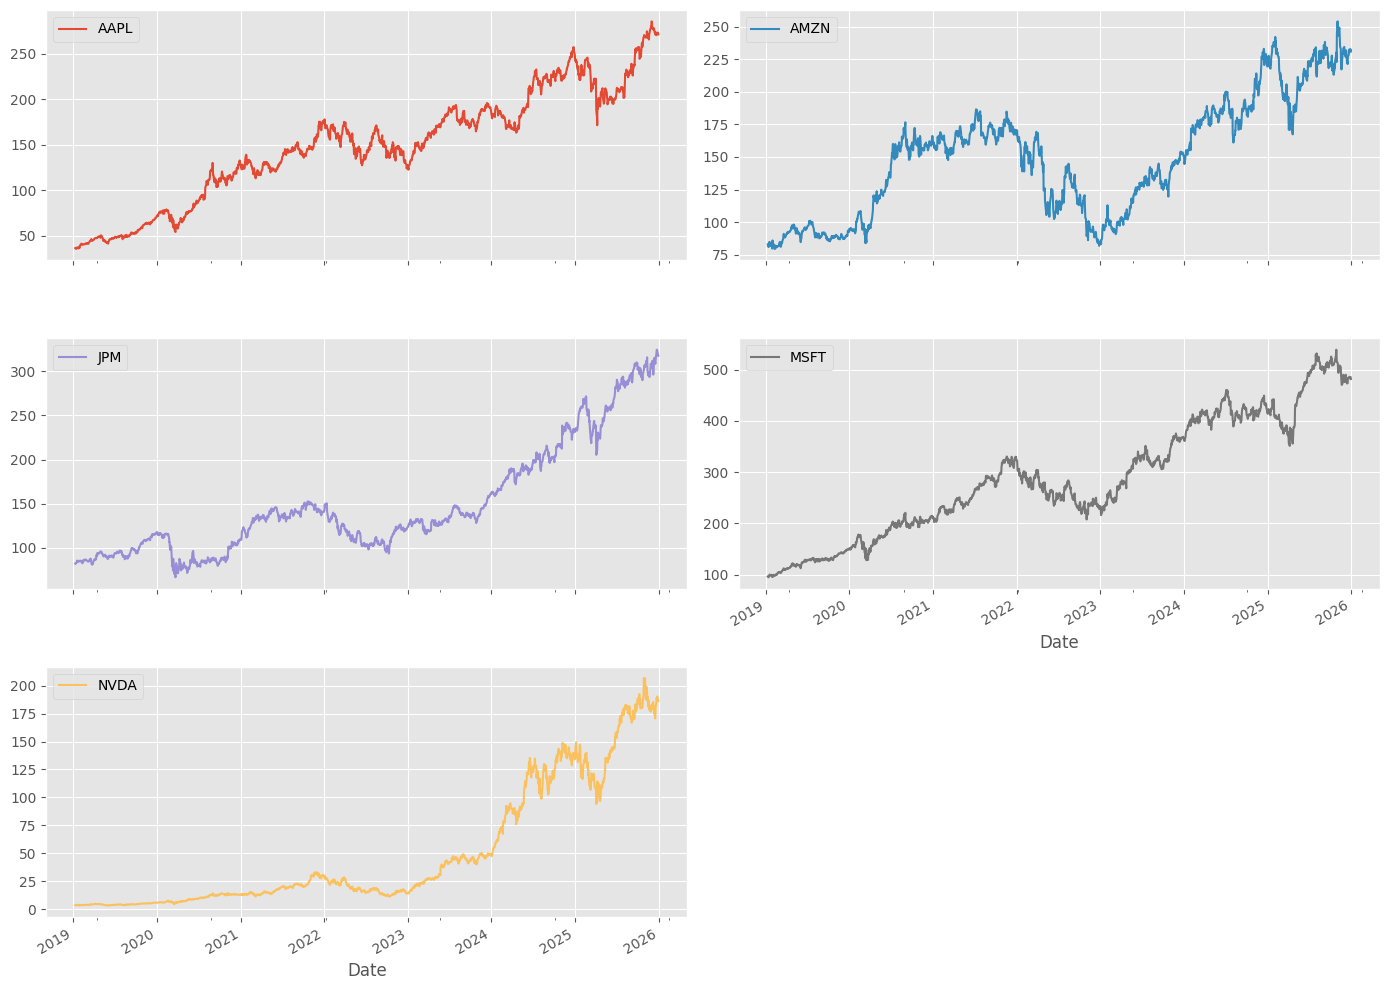

In [17]:
close_prices.plot(
    subplots=True,
    figsize=(14, 10),
    layout=(3, 2),
    sharex=True
)

plt.tight_layout()
plt.show()

In [18]:
!pip install plotly

In [19]:
import plotly.express as px


In [20]:
fig = px.line(
    close_prices,
    x=close_prices.index,
    y=close_prices.columns,
    title="Historical Adjusted Closing Prices"
)

fig.update_layout(
    xaxis_title="Date",
    yaxis_title="Price (USD)"
)

fig.show()

In [21]:
normalized_prices = close_prices / close_prices.iloc[0]
normalized_prices.head()

Ticker,AAPL,AMZN,JPM,MSFT,NVDA
Date,,,,,
2019-01-10,1.000000,1.000000,1.000000,1.000000,1.000000
2019-01-11,0.990182,0.990545,0.995219,0.992278,1.024788
2019-01-14,0.975292,0.976446,1.005479,0.985039,1.035874
2019-01-15,0.995254,1.011073,1.012850,1.013610,1.031949
2019-01-16,1.007412,1.016640,1.021018,1.017182,1.024857


In [22]:
fig = px.line(
    normalized_prices,
    x=normalized_prices.index,
    y=normalized_prices.columns,
    title="Normalized Stock Performance (Base = 1.0)"
)

fig.update_layout(
    template="plotly_white",
    hovermode="x unified",
    xaxis_title="Date",
    yaxis_title="Growth Multiple",
    legend_title="Stocks",
    height=600
)

fig.show()